# Ex 2: Sufficiency Test for $t=1$ to $1$
* drop_leave = True
* Models : XGBoost, LightGBM

## Setup

First, let's import a few common modules.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import pandas as pd
import os

# to make this notebook's output stable across runs
import random
seed_val = 42
np.random.seed(seed_val)
random.seed(seed_val)


## Data Loading and Building Train-set & Test-set

### Dataset Builder : Filtering and Labeling

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def build_dataset(df, t_begin, t_end, drop_leave):
    # --- 1. Validation checks ---
    if t_end == 0 and t_begin != 0:
        raise ValueError("When t_end=0, t_begin must be 0.")
    
    # --- 2. Drop entries with invalid current state ---
    # If t_begin is not 0, exclude rows where the student is already in a dropout/specific state
    if t_begin != 0:
        df = df.loc[~df['state_now'].isin([1, 2]), :].copy()

    # --- 3. Handle Right Censoring ---
    # Remove rows that do not have enough future periods to observe up to t_end
    if t_end == 1:
        censored = (df['year'] == 2023) & (df['semester'] == 2)
    elif t_end == 2:
        censored = (df['year'] == 2023)
    elif t_end == 3:
        censored = (df['year'] == 2023) | ((df['year'] == 2022) & (df['semester'] == 2))
    else:
        censored = pd.Series(False, index=df.index)
    
    if t_end != 0:
        df = df.loc[~censored, :].copy()

    # --- 4. Define relevant state columns ---
    # Includes current state and all future states up to t_end
    state_cols = ['state_now'] + [f'state_next_{i}' for i in range(1, t_end + 1)]

    # --- 5. Determine leave status (state == 3) and filtering ---
    # is_always_leave: Student remains in 'leave' state (3) throughout the entire observation period
    is_always_leave = (df[state_cols] == 3).all(axis=1)
    # is_leave: Student is in 'leave' state (3) at the baseline (t=0 or t=1)
    is_leave = df[state_cols[0 if t_end == 0 else 1]].isin([3])

    if drop_leave == False: 
        # Keep students who are 'always on leave' even if they meet the is_leave criteria
        # This treats consistent leave as a non-dropout case (is_drop=0)
        df = df.loc[~is_leave | is_always_leave, :].copy()
    else:
        # Standard filtering: remove anyone who is on leave at the baseline
        df = df.loc[~is_leave].copy()
    
    # --- 6. Determine dropout status (state == 2) ---
    # Define which columns to check for dropout based on t_begin
    relevant_cols = state_cols if t_begin == 0 else state_cols[1:]
    
    # Label as 1 if state 2 (dropout) appears in any relevant columns, else 0
    # Note: 'always_leave' students kept above will naturally get is_drop = 0
    is_drop = df[relevant_cols].isin([2]).any(axis=1)
    df.loc[:, 'is_drop'] = is_drop.astype(int)

    # --- 7. Finalize dataset ---
    df.reset_index(drop=True, inplace=True)
    return df

### Loading Test-set

In [3]:
seed = 42
df = pd.read_csv(f"../datasets/train_tempo_t2.csv")
train_set = build_dataset(df, t_begin=1, t_end=1, drop_leave=True)
train_set.info()

df = pd.read_csv(f"../datasets/test_tempo_t2.csv")
test_set = build_dataset(df, t_begin=1, t_end=1, drop_leave=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15764 entries, 0 to 15763
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index_o            15764 non-null  int64  
 1   year               15764 non-null  int64  
 2   semester           15764 non-null  int64  
 3   grade              15764 non-null  int64  
 4   sex                15764 non-null  object 
 5   gpa_last_seme      15764 non-null  float64
 6   credits_last_seme  15764 non-null  float64
 7   credits_tot        15764 non-null  float64
 8   n_seme             15764 non-null  int64  
 9   years_since        15764 non-null  int64  
 10  sno_hashed         15764 non-null  object 
 11  state_next_1       15764 non-null  float64
 12  state_next_2       13353 non-null  float64
 13  state_next_3       9807 non-null   float64
 14  state_now          15764 non-null  int64  
 15  college            15764 non-null  object 
 16  adm_unit           157

* Sampling from original train-set to make a smaller train-set

In [4]:
#train_set = train_set.sample(frac=0.8, random_state=42).reset_index(drop=True)

In [5]:
X_train = train_set.drop(['is_drop'], axis=1)
y_train = train_set['is_drop'].copy()

X_test = test_set.drop(['is_drop'], axis=1)
y_test = test_set['is_drop'].copy()

In [6]:
y_train.value_counts()

is_drop
0.0    15148
1.0      616
Name: count, dtype: int64

## Data Transformation

Label encoding for categorical features

In [7]:
def sex_mapping(sex):
    sex_map = {'M': 0, 'F': 1}
    return sex_map[sex]

def seme_mapping(seme): # semester (Spring/Fall)
    seme_map = {1: 0, 2: 1}
    return seme_map[seme]

def college_mapping(college):
    college_map = {'TH': 0, 'HS': 1, 'BZ': 2, 'HT': 3, 'EG': 4, 'SW': 5, 'AT': 6}
    return college_map[college]

def label_encoding(data):
    data['sex'] = data['sex'].map(sex_mapping)
    data['semester'] = data['semester'].map(seme_mapping)
    data['college'] = data['college'].map(college_mapping)

Pipeline for encoding and scaling

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attrs = ['grade', 'gpa_last_seme', 'credits_last_seme', 'credits_tot', 'n_seme', 'years_since']
cat_attrs = ['semester', 'sex', 'adm_unit', 'nation', 'in_capa', 'college', 'leave']

full_pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attrs),
    ('cat', OneHotEncoder(), cat_attrs)
])

cat_pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attrs),
    ('cat', 'passthrough', cat_attrs)
])

# for XGBoost and LightGBM with label encoding
label_encoding(X_train)
X_train = cat_pipeline.fit_transform(X_train) 
X_train = pd.DataFrame(X_train, columns=cat_pipeline.get_feature_names_out()) 


In [9]:
# Typesetting for LGBM
num_cols = ['num__grade', 'num__gpa_last_seme', 'num__credits_last_seme', 'num__credits_tot', 'num__n_seme', 'num__years_since']
            #, 'num__delta_gpa']
cat_cols = list(set(X_train.columns) - set(num_cols))

X_train[num_cols] = X_train[num_cols].astype(float)
X_train[cat_cols] = X_train[cat_cols].astype(int)

In [10]:
label_encoding(X_test)
X_test = cat_pipeline.transform(X_test)
X_test = pd.DataFrame(X_test, columns=cat_pipeline.get_feature_names_out())

# Typesetting
X_test[num_cols] = X_test[num_cols].astype(float)
X_test[cat_cols] = X_test[cat_cols].astype(int)

## Modular Pipeline: Train and Test

In [11]:
import optuna
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (precision_recall_curve, f1_score, average_precision_score, 
                             roc_auc_score, recall_score, precision_score, matthews_corrcoef)

import warnings
warnings.filterwarnings('ignore')

c:\Users\admin\OneDrive\data_sci\college-dropout\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Generalized Objective Function for Optuna

In [12]:
def objective(trial, model_name, X_t, y_t, X_v, y_v):
    pos_weight = (len(y_t) - sum(y_t)) / sum(y_t)
    if model_name == 'xgb':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_estimators': 2000,
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'aucpr',
            'scale_pos_weight': pos_weight
        }
        model = XGBClassifier(**param)
        model.fit(
            X_t, y_t, 
            eval_set=[(X_v, y_v)], 
            early_stopping_rounds=50, 
            verbose=False
        )
        
    elif model_name == 'lgbm':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'num_leaves': trial.suggest_int('num_leaves', 7, 31),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_estimators': 2000,
            'random_state': 42,
            'n_jobs': -1,
            'is_unbalance': True
        }
        model = LGBMClassifier(**param)
        model.fit(
            X_t, y_t, 
            eval_set=[(X_v, y_v)], 
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
    else:
        raise ValueError("Unsupported model_name. Choose 'xgb' or 'lgbm'.")

    # Use predict_proba for AP calculation
    preds_proba = model.predict_proba(X_v)[:, 1]
    return average_precision_score(y_v, preds_proba)

### TRAIN Fuction


In [13]:
def train_model(model_name, X_train, y_train):
    print(f"\n=======================================================")
    print(f"--- Training Model: {model_name.upper()} ---")
    print(f"=======================================================")

    # [Phase 1] Hyperparameter Tuning
    print("--- [Phase 1] Tuning with Optuna ---")
    X_tune_t, X_tune_v, y_tune_t, y_tune_v = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial: objective(trial, model_name, X_tune_t, y_tune_t, X_tune_v, y_tune_v), 
        n_trials=30
    )
    best_params = study.best_params
    print(f"Optimal parameters: {best_params}\n")

    # [Phase 2] K-Fold OOF Training
    print("--- [Phase 2] K-Fold OOF Training ---")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(X_train))
    trained_models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        if model_name == 'xgb':
            model = XGBClassifier(**best_params, n_estimators=5000, random_state=42, eval_metric='aucpr')
            model.fit(X_t, y_t, eval_set=[(X_v, y_v)], early_stopping_rounds=50, verbose=False)
            best_iter = model.get_booster().best_iteration
            
        elif model_name == 'lgbm':
            best_params['subsample_freq'] = 1
            model = LGBMClassifier(**best_params, n_estimators=5000, random_state=42, n_jobs=-1)
            model.fit(
                X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='average_precision',
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
            best_iter = model.best_iteration_
            
        oof_probs[val_idx] = model.predict_proba(X_v)[:, 1]
        trained_models.append(model)
        print(f"  -> Fold {fold+1} completed (Best Iteration: {best_iter})")

    # [Phase 3] OOF Evaluation & Threshold Tuning
    print("\n--- [Phase 3] OOF Evaluation & Threshold Optimization ---")
    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-5)
    best_thre = thresholds[np.argmax(f1_scores)]
    print(f"Optimal Threshold (from OOF): {best_thre:.4f}\n")

    # Calculate OOF Metrics (for checking train-validation performance)
    ap = average_precision_score(y_train, oof_probs)
    auc = roc_auc_score(y_train, oof_probs)
    
    preds_no = (oof_probs > 0.5).astype(int)
    recall_no = recall_score(y_train, preds_no)
    preci_no = precision_score(y_train, preds_no)
    f1_no = f1_score(y_train, preds_no)
    mcc_no = matthews_corrcoef(y_train, preds_no)
    
    preds_opt = (oof_probs > best_thre).astype(int)
    recall_opt = recall_score(y_train, preds_opt)
    preci_opt = precision_score(y_train, preds_opt)
    f1_opt = f1_score(y_train, preds_opt)
    mcc_opt = matthews_corrcoef(y_train, preds_opt)
    
    oof_res = {
        'ap': ap, 'auc': auc, 
        'recall': recall_no, 'precision': preci_no, 'f1': f1_no, 'mcc': mcc_no, 
        'recall(opt)': recall_opt, 'precision(opt)': preci_opt, 'f1(opt)': f1_opt, 'mcc(opt)': mcc_opt, 
        'threshold': best_thre
    }
    
    return trained_models, best_thre, oof_res

### TEST Function

In [14]:
def test_model(trained_models, best_thre, X_test, y_test):
    print("--- [Phase 4] Final Test Evaluation ---")
    
    # Soft voting ensemble
    test_probs_list = [model.predict_proba(X_test)[:, 1] for model in trained_models]
    ensemble_test_probs = np.mean(test_probs_list, axis=0)
    
    # Calculate Probabilistic Metrics
    ap = average_precision_score(y_test, ensemble_test_probs)
    auc = roc_auc_score(y_test, ensemble_test_probs)
    
    # Predictions at Default Threshold (0.5)
    preds_no = (ensemble_test_probs > 0.5).astype(int)
    recall_no = recall_score(y_test, preds_no)
    preci_no = precision_score(y_test, preds_no)
    f1_no = f1_score(y_test, preds_no)
    mcc_no = matthews_corrcoef(y_test, preds_no)
    
    # Predictions at Optimized Threshold
    preds_opt = (ensemble_test_probs > best_thre).astype(int)
    recall_opt = recall_score(y_test, preds_opt)
    preci_opt = precision_score(y_test, preds_opt)
    f1_opt = f1_score(y_test, preds_opt)
    mcc_opt = matthews_corrcoef(y_test, preds_opt)
    
    test_res = {
        'ap': ap, 'auc': auc, 
        'recall': recall_no, 'precision': preci_no, 'f1': f1_no, 'mcc': mcc_no, 
        'recall(opt)': recall_opt, 'precision(opt)': preci_opt, 'f1(opt)': f1_opt, 'mcc(opt)': mcc_opt, 
        'threshold': best_thre
    }
    
    print("Test Evaluation Completed.\n")
    return test_res

In [15]:
y_train.value_counts()

is_drop
0.0    15148
1.0      616
Name: count, dtype: int64

## Execute Experiments and Collect Results

### LightGBM

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set 10 intervals from 10% to 100%
fractions = np.linspace(0.1, 1.0, 10)

val_f1_scores = []
test_f1_scores = []
val_ap_scores = []
test_ap_scores = []
data_sizes = []

print("=======================================================")
print("--- Starting Data Scale Sufficiency Experiment ---")
print("=======================================================")

for frac in fractions:
    print(f"\n\n>>> Data Fraction: {frac*100:.0f}% <<<")
    
    # 1. Subset training data (Maintain target imbalance ratio using 'stratify')
    if frac < 1.0:
        X_sub, X_drop, y_sub, y_drop = train_test_split(
            X_train, y_train, 
            train_size=frac, 
            stratify=y_train, 
            random_state=42
        )
    else:
        # Use the entire dataset when fraction is 100%
        X_sub, y_sub = X_train.copy(), y_train.copy()
        
    data_sizes.append(len(X_sub))
    
    # 2. Train LightGBM model only (Optuna tuning -> OOF CV 5-Fold -> Optimal threshold)
    models, best_thre, oof_res = train_model('lgbm', X_sub, y_sub)
    
    # 3. Final evaluation with Test set (Test set remains fixed across all fractions)
    test_res = test_model(models, best_thre, X_test, y_test)
    
    # 4. Store F1-Score (opt) and AP scores respectively
    val_f1_scores.append(oof_res['f1(opt)'])
    test_f1_scores.append(test_res['f1(opt)'])
    
    val_ap_scores.append(oof_res['ap'])
    test_ap_scores.append(test_res['ap'])


--- Starting Data Scale Sufficiency Experiment ---


>>> Data Fraction: 10% <<<

--- Training Model: LGBM ---
--- [Phase 1] Tuning with Optuna ---
[LightGBM] [Info] Number of positive: 50, number of negative: 1210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 1260, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039683 -> initscore=-3.186353
[LightGBM] [Info] Start training from score -3.186353
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

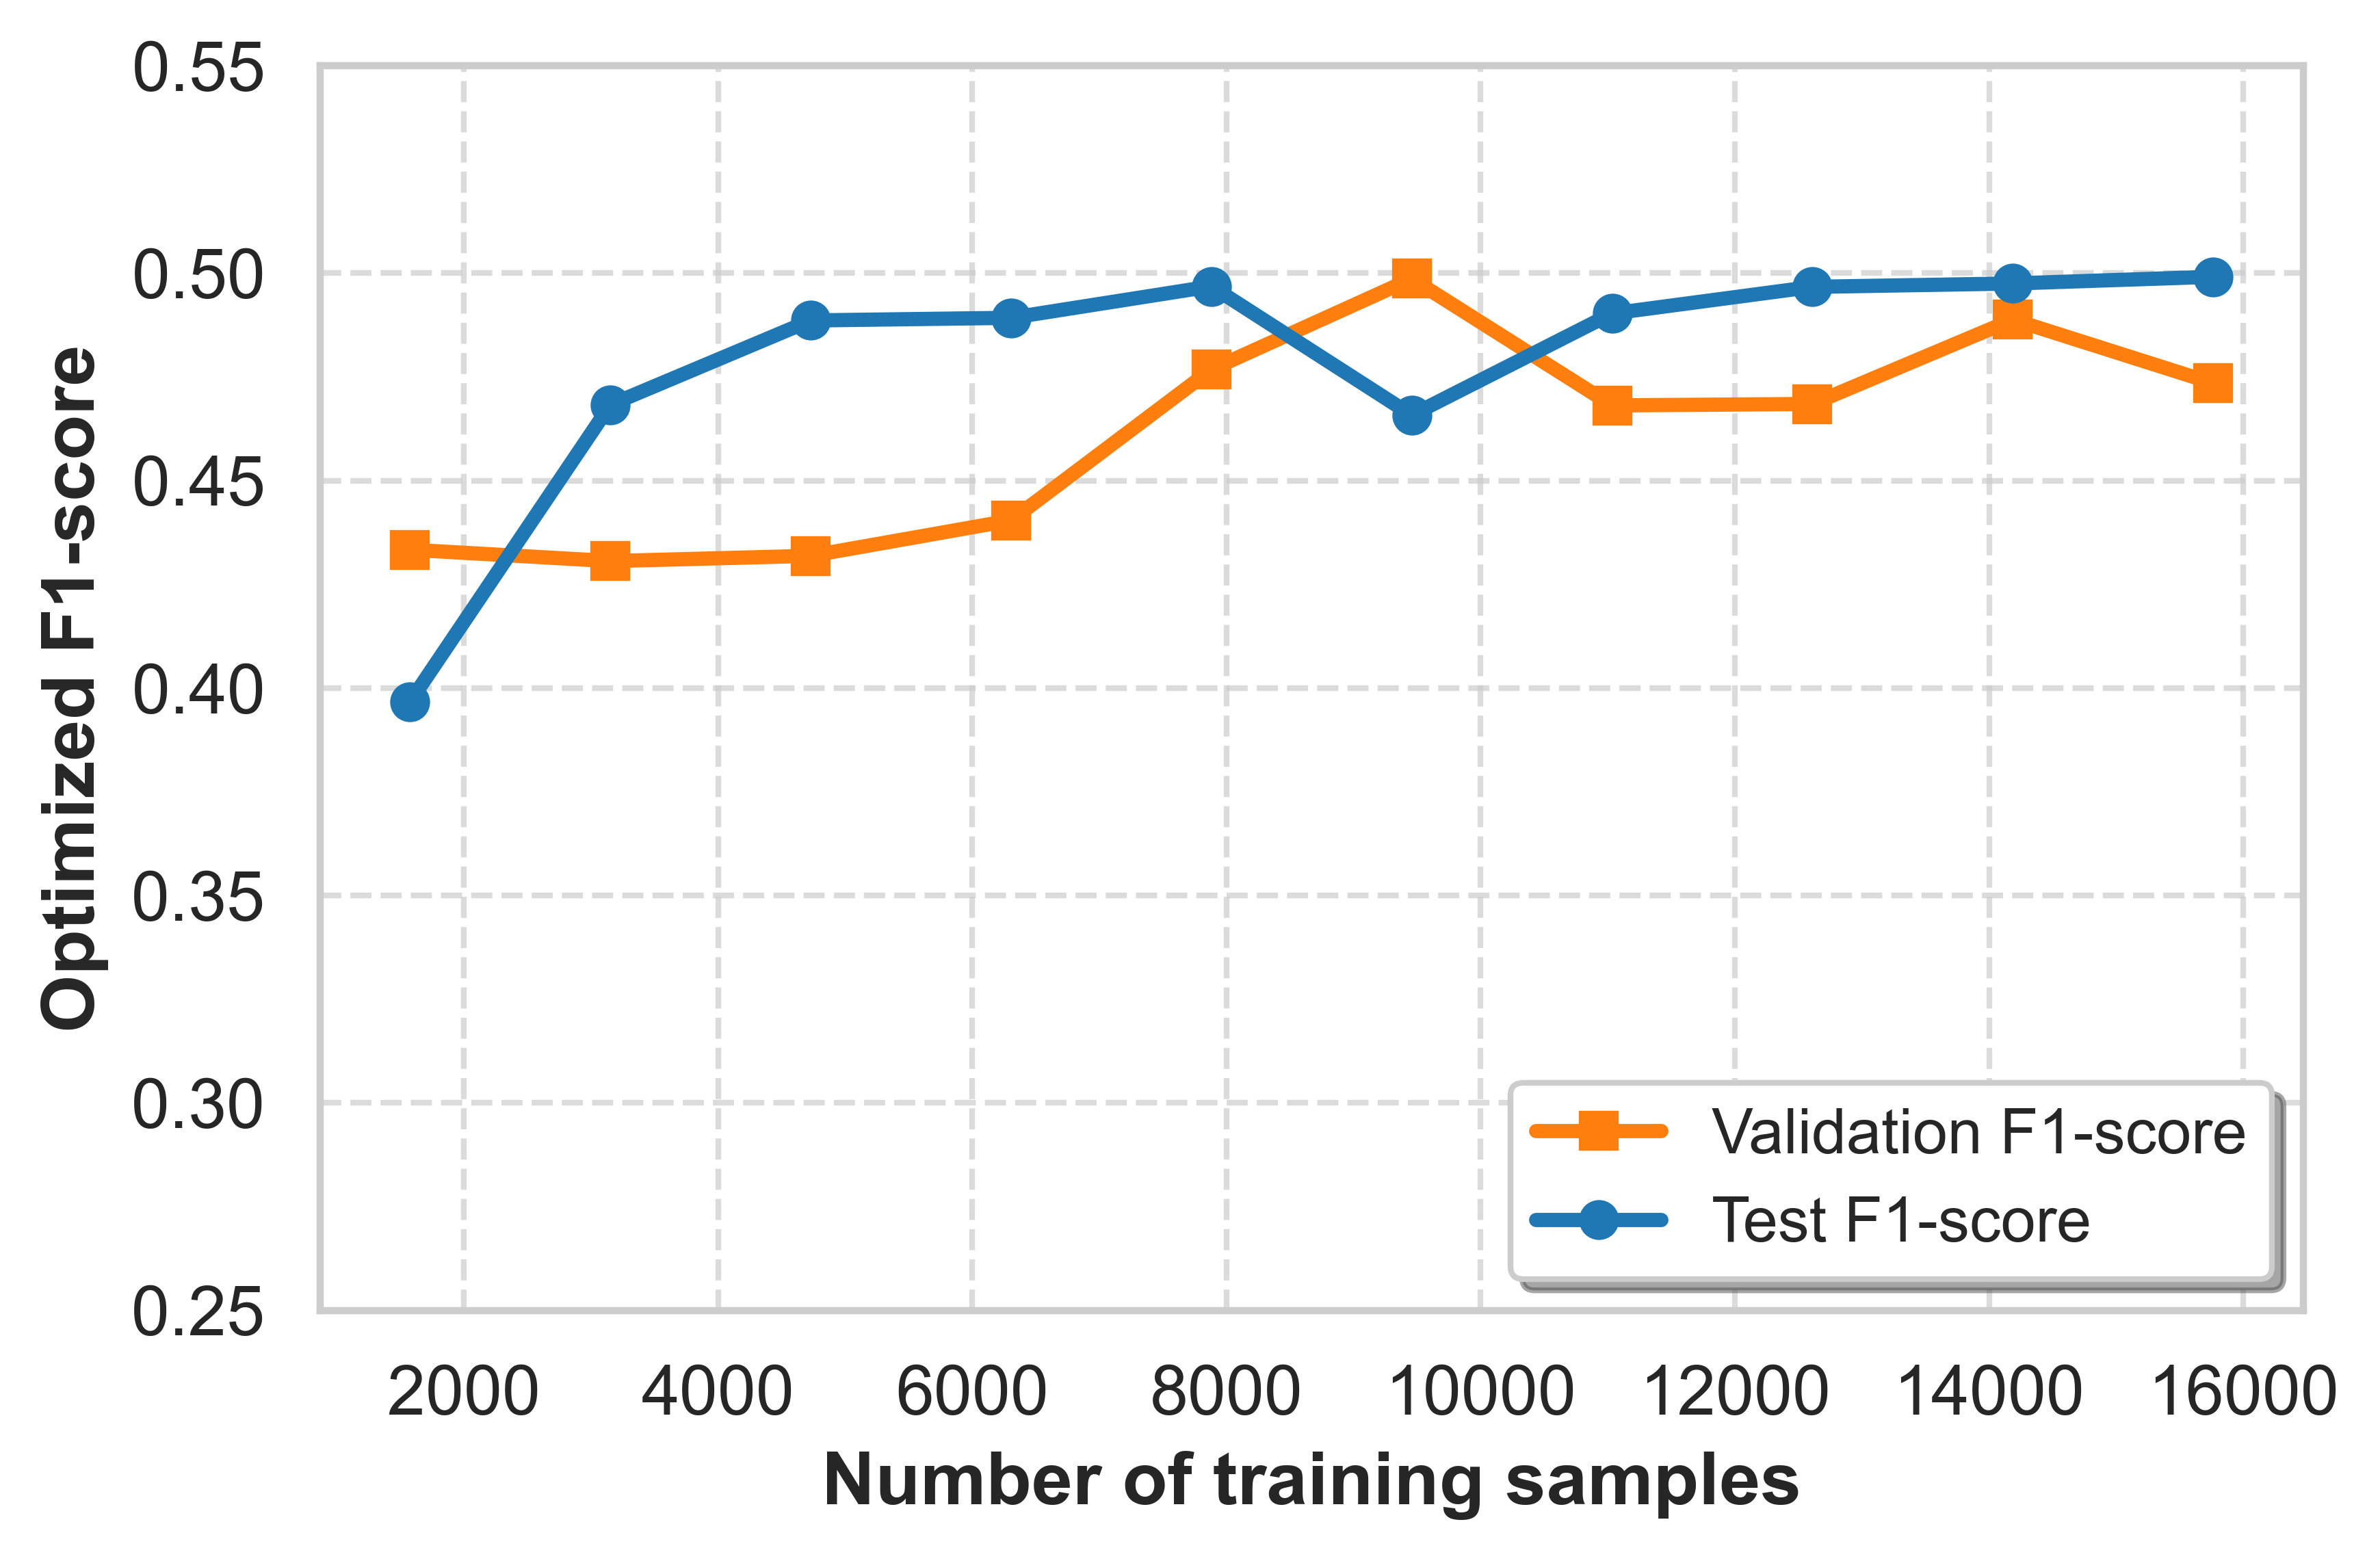

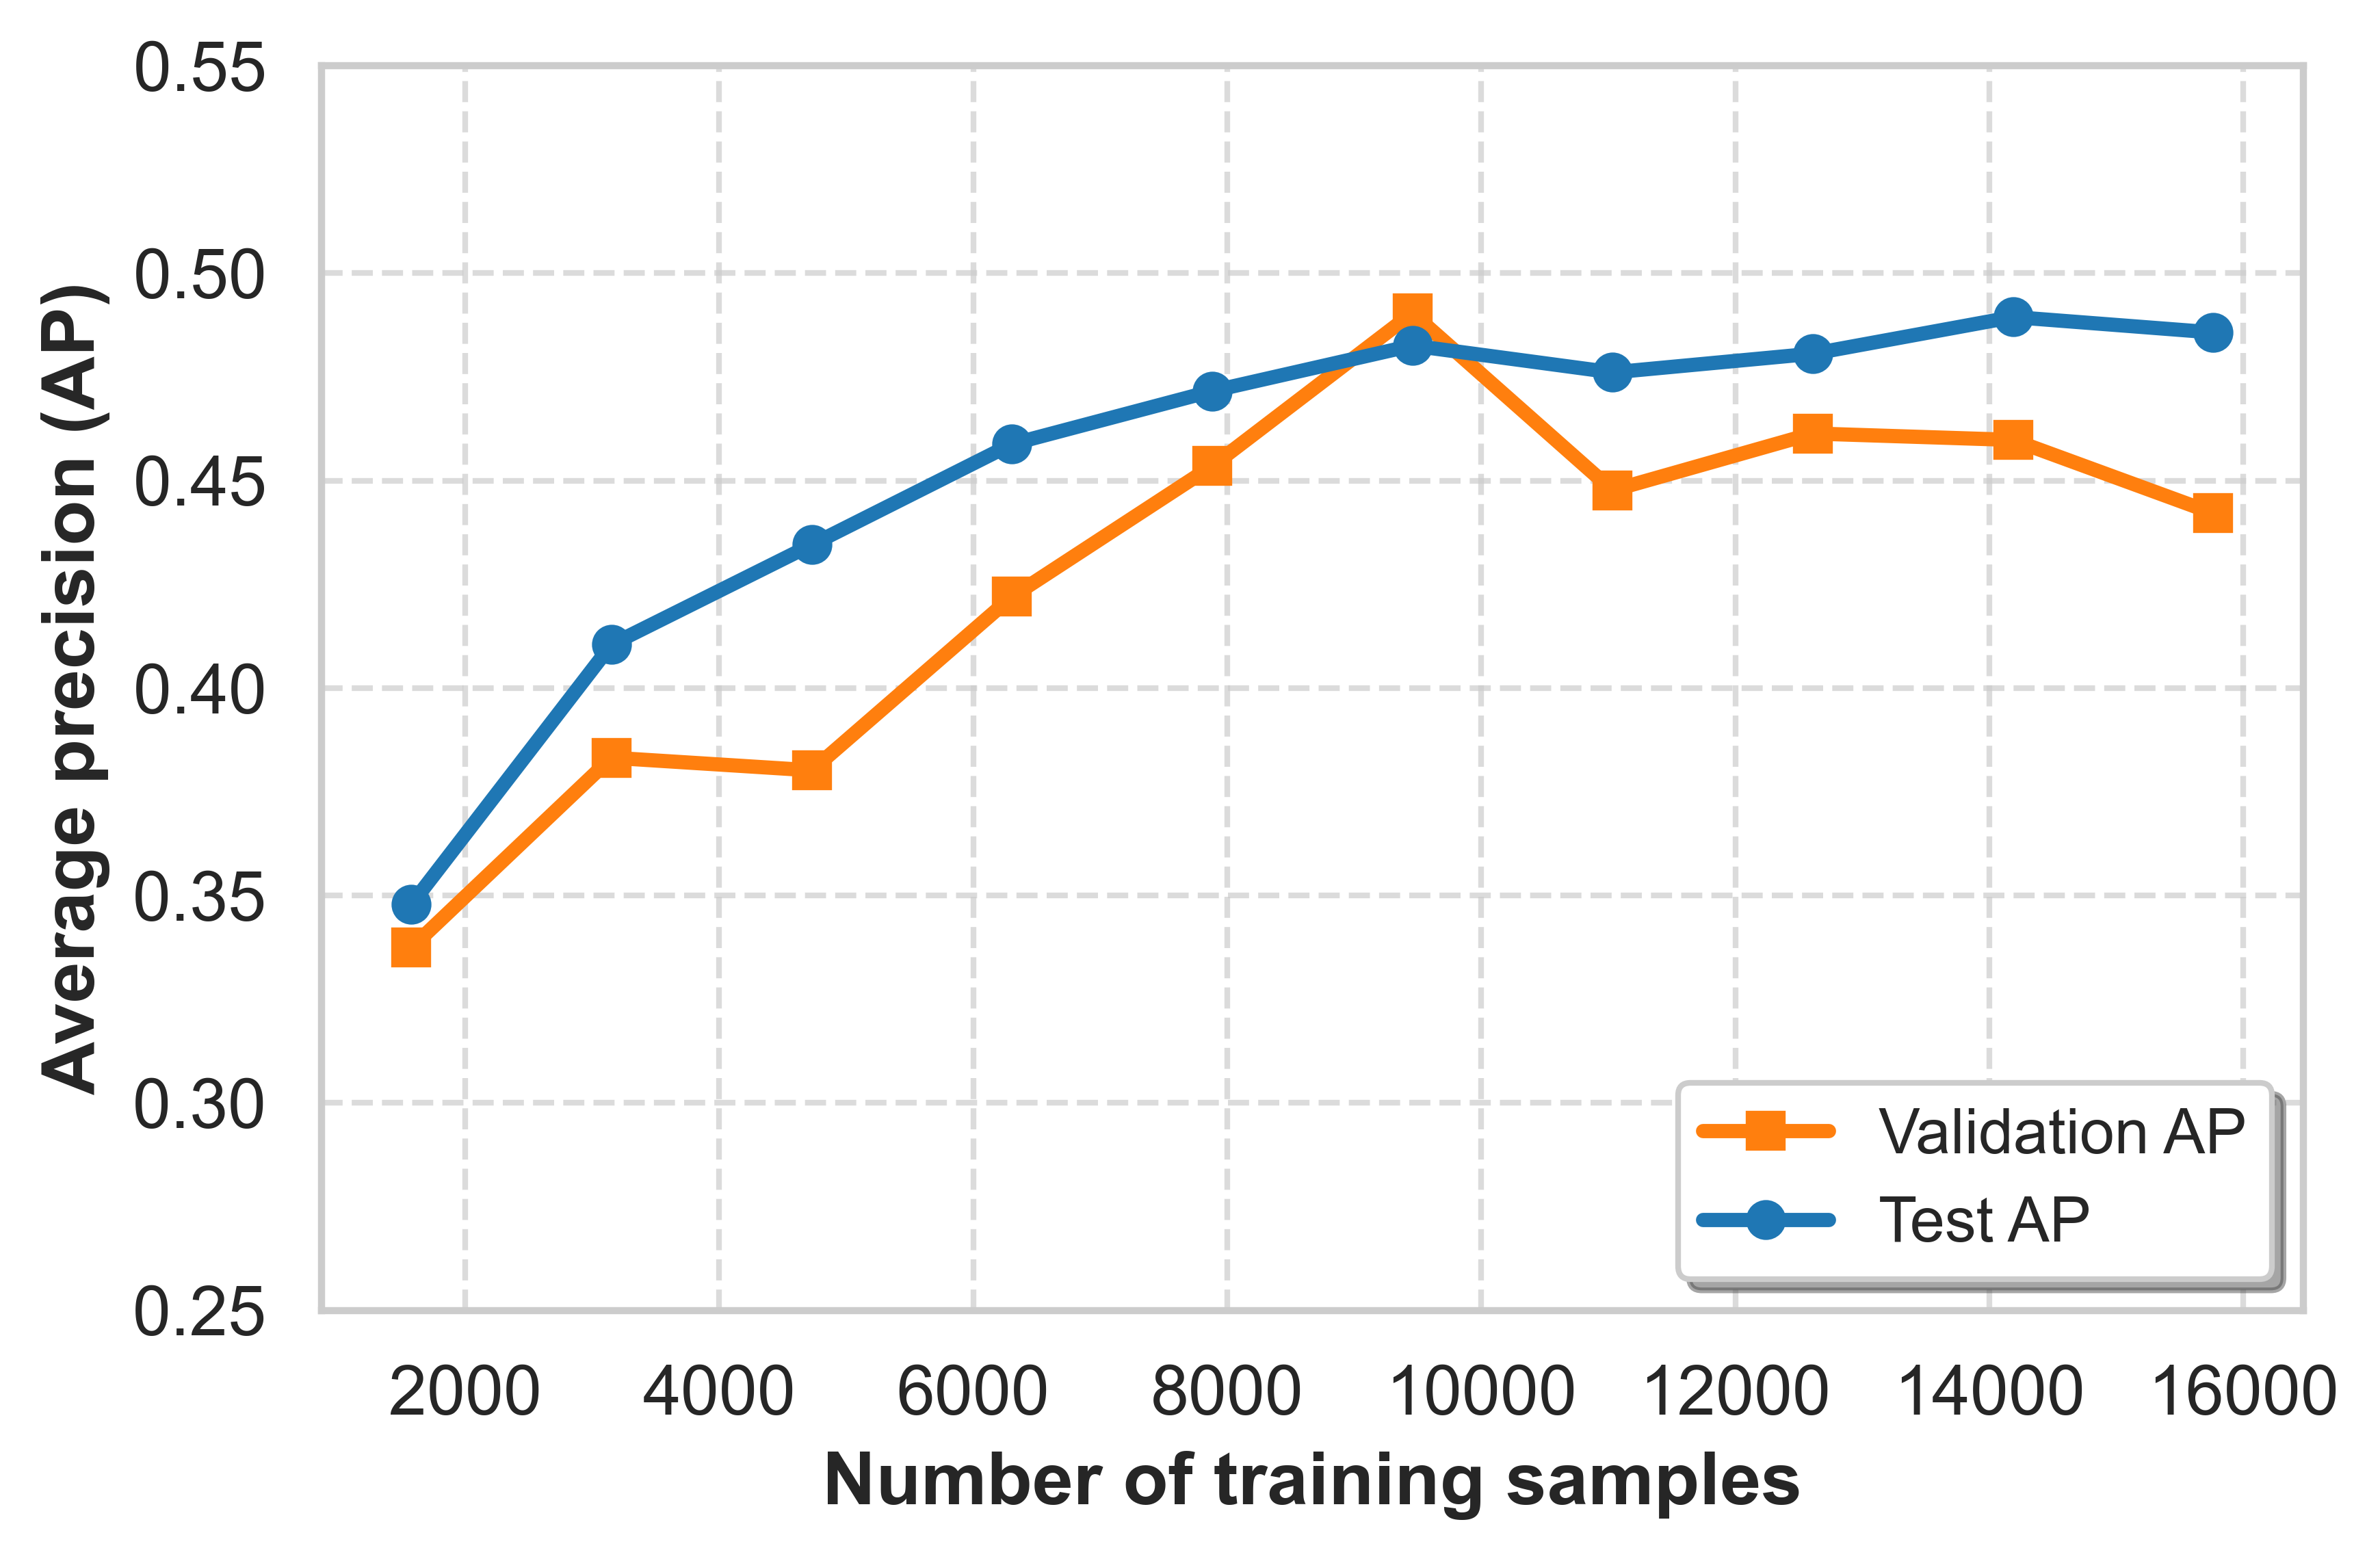

In [ ]:
import seaborn as sns

# ==========================================
# Plot results 1: Optimized F1-Score
# ==========================================
sns.set_theme(style="whitegrid", font_scale=1.1) 
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(6, 4), dpi=600) # 단일 그래프용 비율 및 고해상도 설정

plt.plot(data_sizes, val_f1_scores, 's-', color="#ff7f0e", linewidth=2.5, label="Validation (OOF)")
plt.plot(data_sizes, test_f1_scores, 'o-', color="#1f77b4", linewidth=2.5, label="Test")

# Set title and labels
# plt.title("Learning Curve: Optimized F1-score (LightGBM)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of training samples", fontsize=13, weight='bold')
plt.ylabel("Optimized F1-score", fontsize=13, weight='bold')

# Set y-axis limits and ticks for better visualization
plt.ylim(0.25, 0.55)
plt.yticks(np.arange(0.25, 0.60, 0.05))

# Add legend and grid
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the first figure
plt.tight_layout()
plt.savefig('../figs/learning_curve_f1_t1.jpg', dpi=600, format='jpg', bbox_inches='tight')
plt.show()

# ==========================================
# Plot results 2: Average Precision (AP)
# ==========================================
plt.figure(figsize=(6, 4), dpi=600) # 두 번째 그래프 생성

plt.plot(data_sizes, val_ap_scores, 's-', color="#ff7f0e", linewidth=2.5, label="Validation (OOF)")
plt.plot(data_sizes, test_ap_scores, 'o-', color="#1f77b4", linewidth=2.5, label="Test")

# Set title and labels
# plt.title("Learning Curve: Average Precision (LightGBM)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of training samples", fontsize=13, weight='bold')
plt.ylabel("Average precision (AP)", fontsize=13, weight='bold')
# Set y-axis limits and ticks for better visualization
plt.ylim(0.25, 0.55)
plt.yticks(np.arange(0.25, 0.60, 0.05))

# Add legend and grid
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the second figure
plt.tight_layout()
plt.savefig('../figs/learning_curve_ap_t1.jpg', dpi=600, format='jpg', bbox_inches='tight')
plt.show()

### XGBoost

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set 10 intervals from 10% to 100%
fractions = np.linspace(0.1, 1.0, 10)

val_f1_scores = []
test_f1_scores = []
val_ap_scores = []
test_ap_scores = []
data_sizes = []

print("=======================================================")
print("--- Starting Data Scale Sufficiency Experiment ---")
print("=======================================================")

for frac in fractions:
    print(f"\n\n>>> Data Fraction: {frac*100:.0f}% <<<")
    
    # 1. Subset training data (Maintain target imbalance ratio using 'stratify')
    if frac < 1.0:
        X_sub, X_drop, y_sub, y_drop = train_test_split(
            X_train, y_train, 
            train_size=frac, 
            stratify=y_train, 
            random_state=42
        )
    else:
        # Use the entire dataset when fraction is 100%
        X_sub, y_sub = X_train.copy(), y_train.copy()
        
    data_sizes.append(len(X_sub))
    
    # 2. Train LightGBM model only (Optuna tuning -> OOF CV 5-Fold -> Optimal threshold)
    models, best_thre, oof_res = train_model('xgb', X_sub, y_sub)
    
    # 3. Final evaluation with Test set (Test set remains fixed across all fractions)
    test_res = test_model(models, best_thre, X_test, y_test)
    
    # 4. Store F1-Score (opt) and AP scores respectively
    val_f1_scores.append(oof_res['f1(opt)'])
    test_f1_scores.append(test_res['f1(opt)'])
    
    val_ap_scores.append(oof_res['ap'])
    test_ap_scores.append(test_res['ap'])


--- Starting Data Scale Sufficiency Experiment ---


>>> Data Fraction: 10% <<<

--- Training Model: XGB ---
--- [Phase 1] Tuning with Optuna ---
Optimal parameters: {'learning_rate': 0.050010320152306637, 'max_depth': 4, 'subsample': 0.7020228276855583, 'colsample_bytree': 0.9610711153089428}

--- [Phase 2] K-Fold OOF Training ---
  -> Fold 1 completed (Best Iteration: 117)
  -> Fold 2 completed (Best Iteration: 34)
  -> Fold 3 completed (Best Iteration: 6)
  -> Fold 4 completed (Best Iteration: 1)
  -> Fold 5 completed (Best Iteration: 47)

--- [Phase 3] OOF Evaluation & Threshold Optimization ---
Optimal Threshold (from OOF): 0.1369

--- [Phase 4] Final Test Evaluation ---
Test Evaluation Completed.



>>> Data Fraction: 20% <<<

--- Training Model: XGB ---
--- [Phase 1] Tuning with Optuna ---
Optimal parameters: {'learning_rate': 0.07953880616242538, 'max_depth': 4, 'subsample': 0.6067731521561825, 'colsample_bytree': 0.8349855842524363}

--- [Phase 2] K-Fold OOF Training ---
  -> 

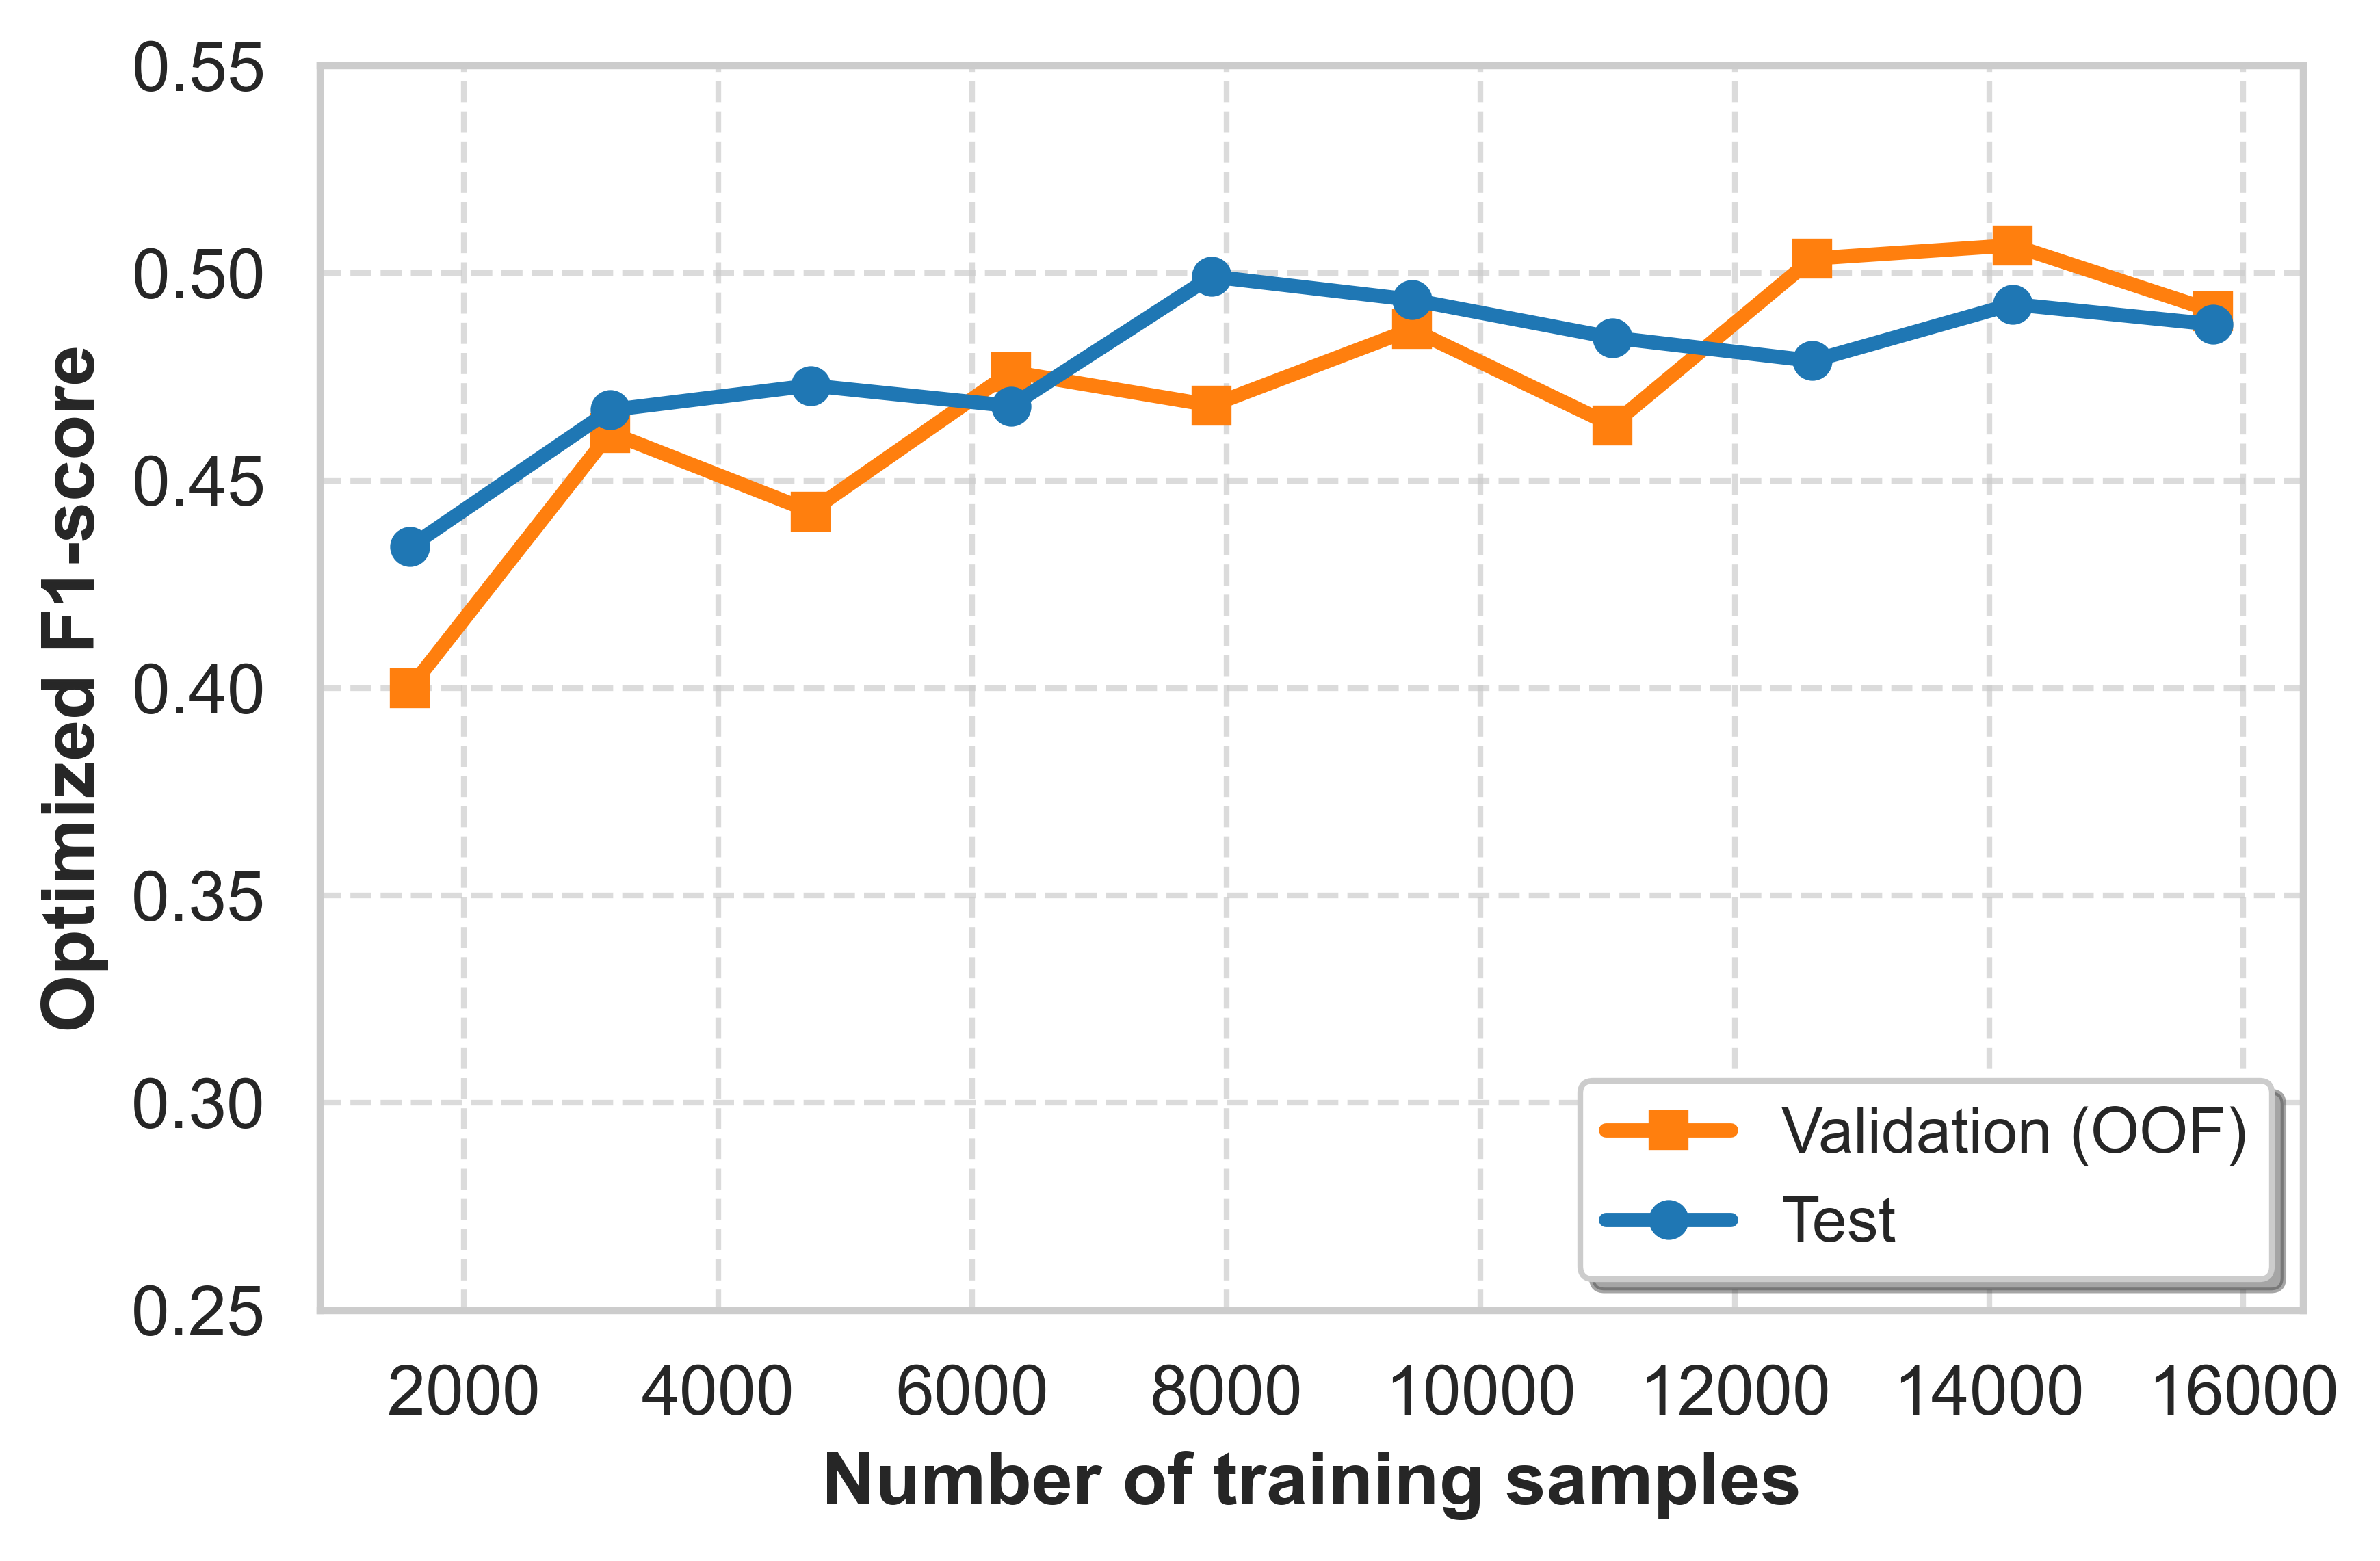

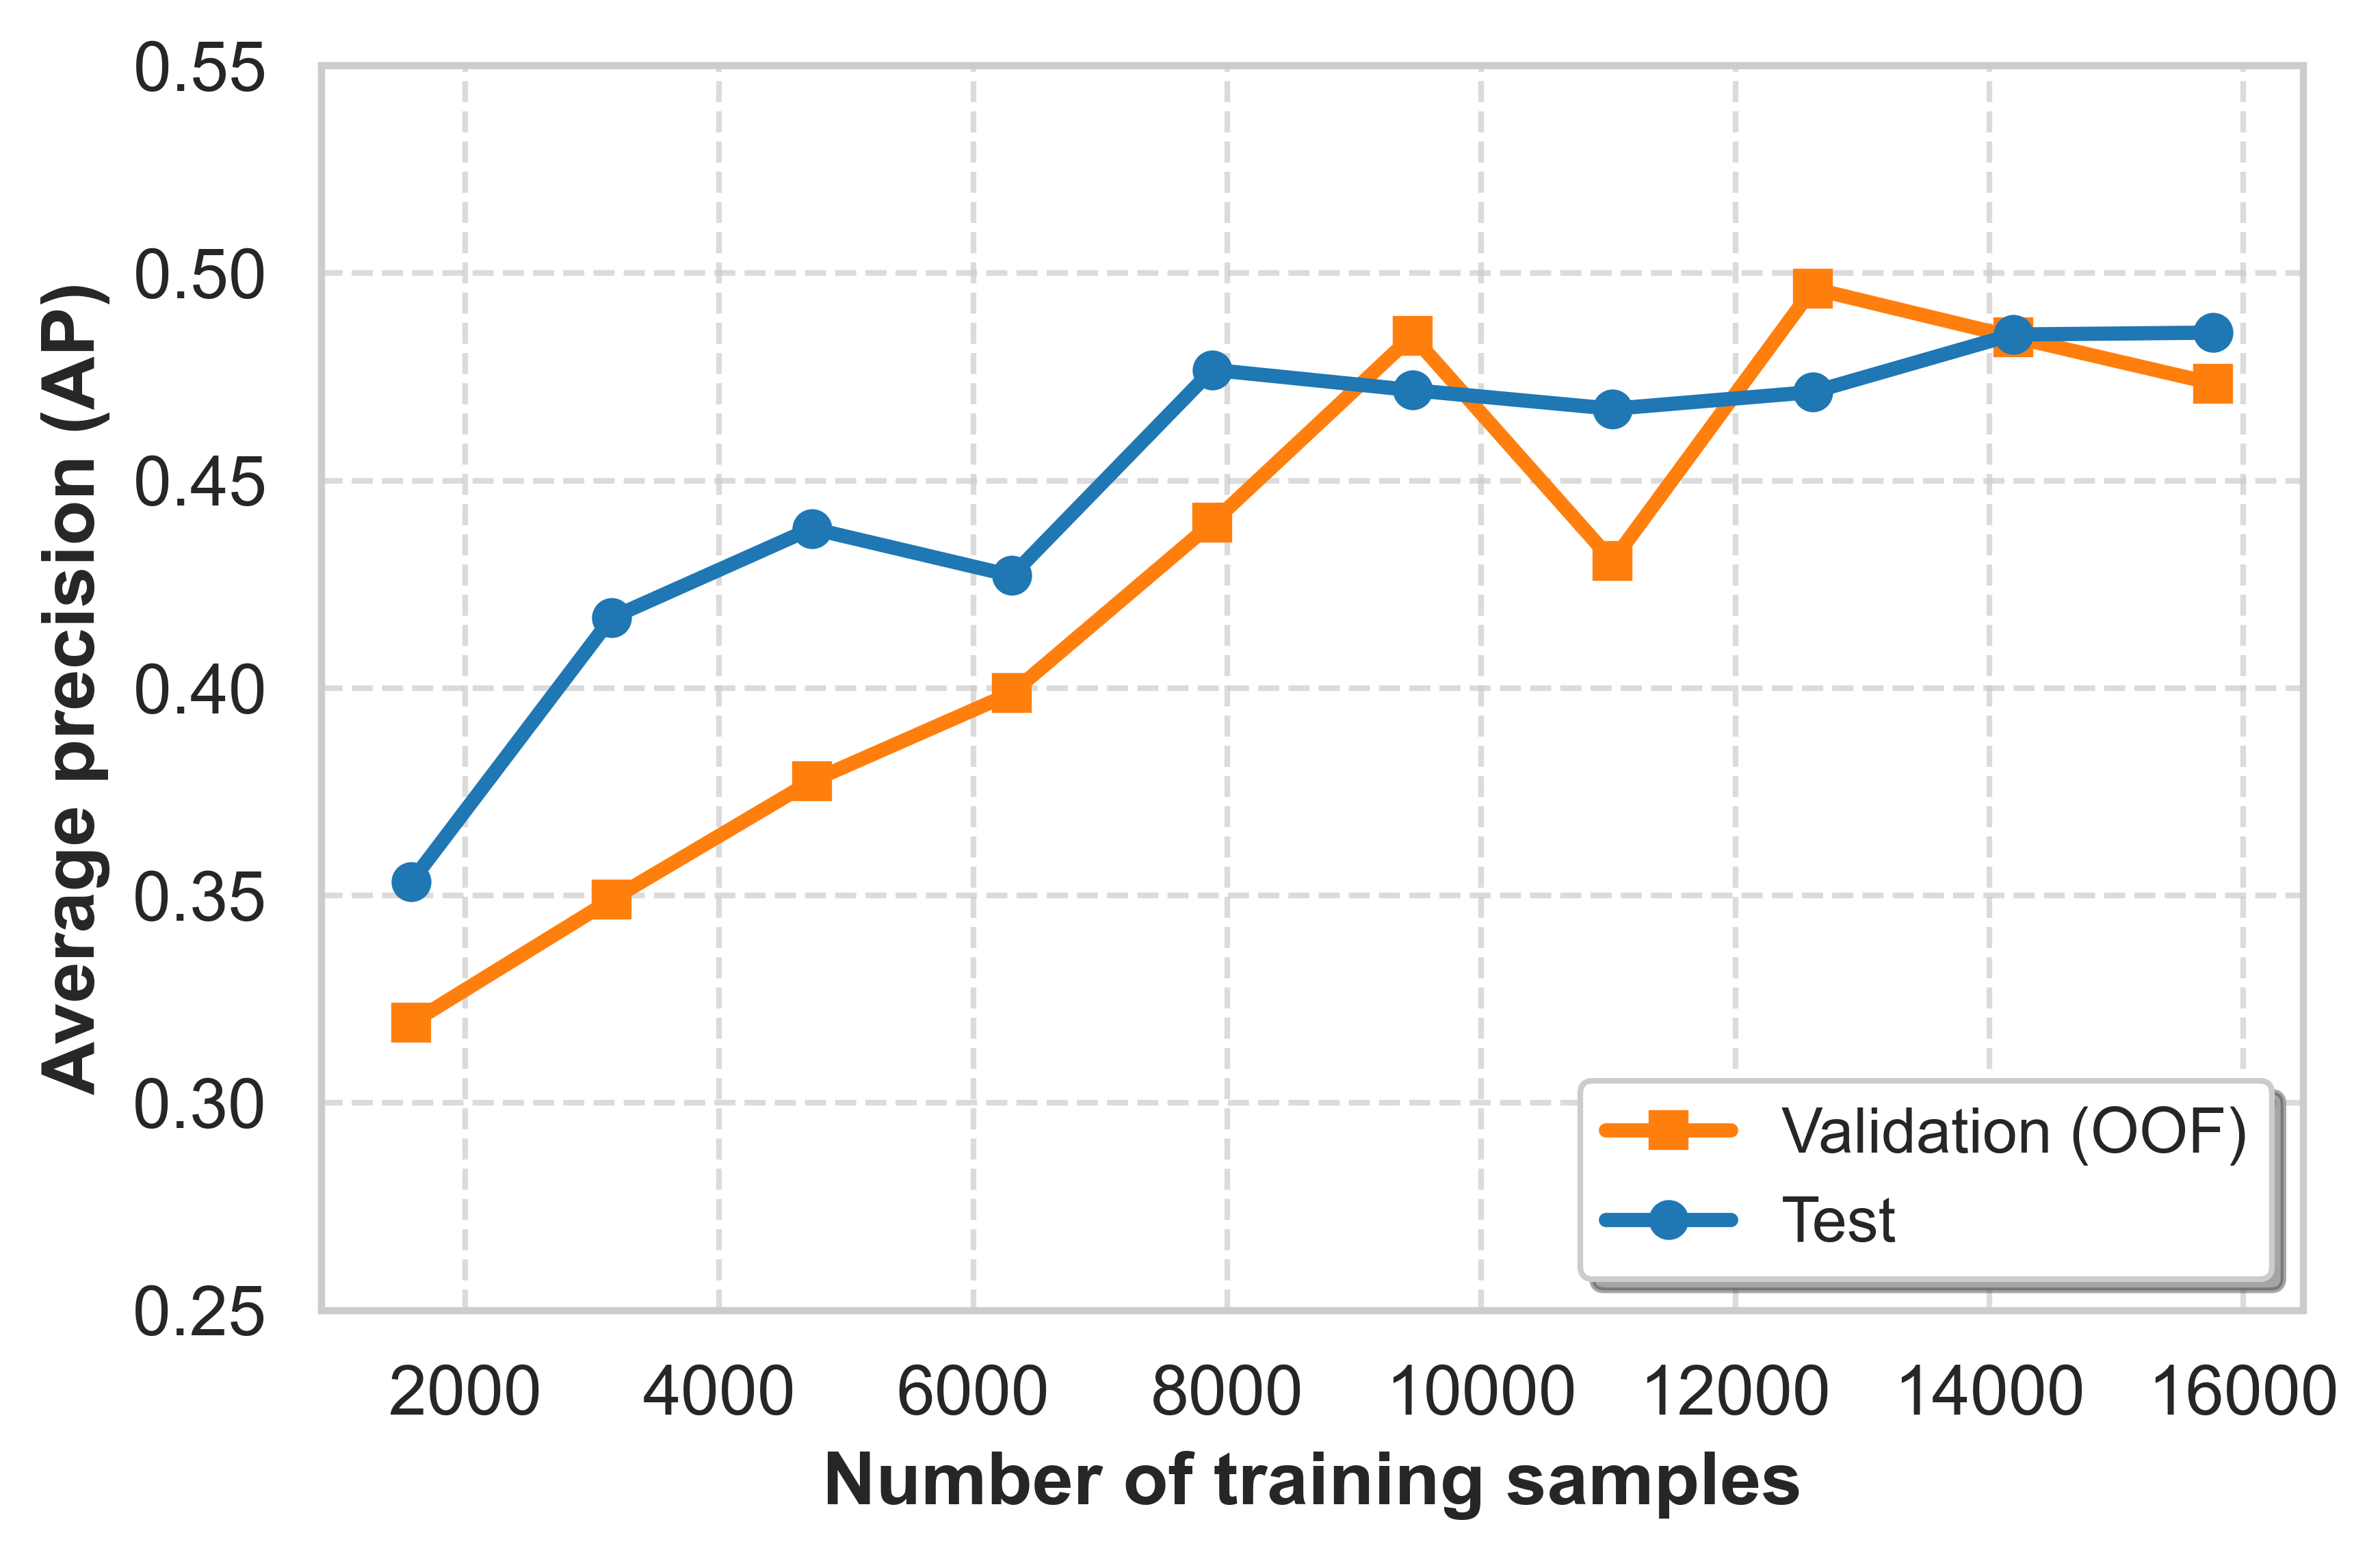

In [18]:
import seaborn as sns

# ==========================================
# Plot results 1: Optimized F1-Score
# ==========================================
sns.set_theme(style="whitegrid", font_scale=1.1) 
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(6, 4), dpi=600) # 단일 그래프용 비율 및 고해상도 설정

plt.plot(data_sizes, val_f1_scores, 's-', color="#ff7f0e", linewidth=2.5, label="Validation (OOF)")
plt.plot(data_sizes, test_f1_scores, 'o-', color="#1f77b4", linewidth=2.5, label="Test")

# Set title and labels
# plt.title("Learning Curve: Optimized F1-score (LightGBM)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of training samples", fontsize=13, weight='bold')
plt.ylabel("Optimized F1-score", fontsize=13, weight='bold')

# Set y-axis limits and ticks for better visualization
plt.ylim(0.25, 0.55)
plt.yticks(np.arange(0.25, 0.60, 0.05))

# Add legend and grid
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the first figure
plt.tight_layout()
plt.savefig('../figs/learning_curve_f1_t1.jpg', dpi=600, format='jpg', bbox_inches='tight')
plt.show()

# ==========================================
# Plot results 2: Average Precision (AP)
# ==========================================
plt.figure(figsize=(6, 4), dpi=600) # 두 번째 그래프 생성

plt.plot(data_sizes, val_ap_scores, 's-', color="#ff7f0e", linewidth=2.5, label="Validation (OOF)")
plt.plot(data_sizes, test_ap_scores, 'o-', color="#1f77b4", linewidth=2.5, label="Test")

# Set title and labels
# plt.title("Learning Curve: Average Precision (LightGBM)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of training samples", fontsize=13, weight='bold')
plt.ylabel("Average precision (AP)", fontsize=13, weight='bold')
# Set y-axis limits and ticks for better visualization
plt.ylim(0.25, 0.55)
plt.yticks(np.arange(0.25, 0.60, 0.05))

# Add legend and grid
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and save the second figure
plt.tight_layout()
plt.savefig('../figs/learning_curve_ap_t1.jpg', dpi=600, format='jpg', bbox_inches='tight')
plt.show()